In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import time
import os
import shutil
import random
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [6]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eitharmoutasim
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:13<00:00, 55.5MB/s]


In [7]:
import os
import shutil
import random
from pathlib import Path

ORIGINAL_DATASET_PATH = '/content/animal-faces/afhq'
NEW_DATASET_PATH = '/content/animal_faces'

def prepare_dataset():
    print(f"🚀 Preparing new dataset structure at '{NEW_DATASET_PATH}'...")

    classes = ['cat', 'dog', 'wild']

    # 1. Create the new directory structure
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(NEW_DATASET_PATH, split, cls), exist_ok=True)

    # 2. Process each class
    for cls in classes:

        # --- PART A: HANDLE TRAINING DATA (UNTOUCHED) ---
        src_train = Path(ORIGINAL_DATASET_PATH) / 'train' / cls
        if not src_train.exists() and cls == 'wild':
            src_train = Path(ORIGINAL_DATASET_PATH) / 'train' / 'wildlife'

        if src_train.exists():
            train_imgs = list(src_train.glob('*.*'))
            print(f"  📂 {cls.capitalize()} Train: {len(train_imgs)} images (copied 100% untouched)")
            for img in train_imgs:
                shutil.copy(img, os.path.join(NEW_DATASET_PATH, 'train', cls, img.name))

        # --- PART B: HANDLE VAL & TEST DATA (SPLIT) ---
        src_val = Path(ORIGINAL_DATASET_PATH) / 'val' / cls
        if not src_val.exists() and cls == 'wild':
            src_val = Path(ORIGINAL_DATASET_PATH) / 'val' / 'wildlife'

        if src_val.exists():
            val_imgs = list(src_val.glob('*.*'))

            # Shuffle to ensure a random, unbiased split
            random.shuffle(val_imgs)
            total = len(val_imgs)

            # Split: 80% to new val, 20% to new test
            split_idx = int(0.8 * total)

            new_val_imgs = val_imgs[:split_idx]
            new_test_imgs = val_imgs[split_idx:]

            print(f"  📂 {cls.capitalize()} Val/Test: {total} total -> New Val: {len(new_val_imgs)}, New Test: {len(new_test_imgs)}")

            for img in new_val_imgs:
                shutil.copy(img, os.path.join(NEW_DATASET_PATH, 'val', cls, img.name))
            for img in new_test_imgs:
                shutil.copy(img, os.path.join(NEW_DATASET_PATH, 'test', cls, img.name))

    print("✅ Dataset preparation complete! Ready to use.")

# Run the function
prepare_dataset()

🚀 Preparing new dataset structure at '/content/animal_faces'...
  📂 Cat Train: 5153 images (copied 100% untouched)
  📂 Cat Val/Test: 500 total -> New Val: 400, New Test: 100
  📂 Dog Train: 4739 images (copied 100% untouched)
  📂 Dog Val/Test: 500 total -> New Val: 400, New Test: 100
  📂 Wild Train: 4738 images (copied 100% untouched)
  📂 Wild Val/Test: 500 total -> New Val: 400, New Test: 100
✅ Dataset preparation complete! Ready to use.


In [8]:
# ==============================================================================
# 1. DATASET CLASS
# ==============================================================================
class AnimalFacesDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode='train',
                 image_extensions=('.jpg', '.jpeg', '.png', '.bmp')):
        super().__init__()
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.mode = mode
        self.image_extensions = image_extensions

        self.samples = []
        self.class_to_idx = {'cat': 0, 'dog': 1, 'wild': 2}

        mode_dir = self.root_dir / mode

        if not mode_dir.exists():
            raise ValueError(f"Directory {mode_dir} does not exist.")

        for class_name in self.class_to_idx.keys():
            class_dir = mode_dir / class_name

            if not class_dir.exists():
                print(f"Warning: {class_dir} does not exist")
                continue

            for ext in self.image_extensions:
                image_files = list(class_dir.glob(f"*{ext}"))
                for image_path in image_files:
                    self.samples.append({
                        'path': str(image_path),
                        'label': self.class_to_idx[class_name],
                        'class_name': class_name
                    })

        print(f"Loaded {len(self.samples)} images for {mode} set")

        if mode == 'train' and transform is None:
            self.transform = self.get_default_train_transform()
        # ✅ CHANGED: Look for 'val' and 'test' instead of 'validation'
        elif mode in ['val', 'test'] and transform is None:
            self.transform = self.get_default_val_transform()

    def get_default_train_transform(self):
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomRotation(15),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def get_default_val_transform(self):
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            image = Image.open(sample['path']).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, sample['label']
        except Exception as e:
            print(f"Error loading {sample['path']}: {e}")
            return torch.zeros((3, 224, 224)), sample['label']

In [9]:
print("\n" + "="*60)
print("TESTING Animal Faces Data")
print("="*60)
data_file_path = '/content/animal_faces'
animal_dataset = AnimalFacesDataset(data_file_path, mode='train')

print(f"\nDataset length: {len(animal_dataset)}")
print("\nSample items:")
for i in range(5):
    image, label = animal_dataset[i]
    print(f"Sample {i}: Image shape: {image.shape}, Label: {label}")
    print(f"   Image Tensor: {image}")


TESTING Animal Faces Data
Loaded 14630 images for train set

Dataset length: 14630

Sample items:
Sample 0: Image shape: torch.Size([3, 224, 224]), Label: 0
   Image Tensor: tensor([[[-1.8782, -1.8782, -1.8782,  ..., -1.8782, -1.8782, -1.8782],
         [-1.8782, -1.8782, -1.8782,  ..., -1.8782, -1.8782, -1.8782],
         [-1.8782, -1.8782, -1.8782,  ..., -1.8782, -1.8782, -1.8782],
         ...,
         [-1.8782, -1.8782, -1.8782,  ..., -1.8782, -1.8782, -1.8782],
         [-1.8782, -1.8782, -1.8782,  ..., -1.8782, -1.8782, -1.8782],
         [-1.8782, -1.8782, -1.8782,  ..., -1.8782, -1.8782, -1.8782]],

        [[-1.7906, -1.7906, -1.7906,  ..., -1.7906, -1.7906, -1.7906],
         [-1.7906, -1.7906, -1.7906,  ..., -1.7906, -1.7906, -1.7906],
         [-1.7906, -1.7906, -1.7906,  ..., -1.7906, -1.7906, -1.7906],
         ...,
         [-1.7906, -1.7906, -1.7906,  ..., -1.7906, -1.7906, -1.7906],
         [-1.7906, -1.7906, -1.7906,  ..., -1.7906, -1.7906, -1.7906],
         [-1.7

In [10]:
print("\n" + "="*60)
print("DICTIONARY INFO SUMMARY (self.samples)")
print("="*60)
data_file_path = '/content/animal-faces/afhq'
animal_dataset = AnimalFacesDataset(data_file_path, mode='train')

# 1. Extract structural info from the first item
if len(animal_dataset.samples) > 0:
    first_sample = animal_dataset.samples[0]
    dict_keys = list(first_sample.keys())
    value_types = {key: type(value).__name__ for key, value in first_sample.items()}
else:
    dict_keys, value_types = [], {}

# 2. Calculate the distribution summary across the list of dictionaries
class_counts = {}
for sample in animal_dataset.samples:
    name = sample['class_name']
    class_counts[name] = class_counts.get(name, 0) + 1

# Print the summary report
print(f"\nTotal Dictionaries in List : {len(animal_dataset.samples)}")
print(f"Dictionary Keys            : {dict_keys}")
print(f"Value Data Types           : {value_types}")

print("\nClass Distribution Summary inside the Dictionary List:")
for class_name, count in class_counts.items():
    print(f"  - '{class_name}' (Label {animal_dataset.class_to_idx[class_name]}): {count} images")


DICTIONARY INFO SUMMARY (self.samples)
Loaded 14630 images for train set

Total Dictionaries in List : 14630
Dictionary Keys            : ['path', 'label', 'class_name']
Value Data Types           : {'path': 'str', 'label': 'int', 'class_name': 'str'}

Class Distribution Summary inside the Dictionary List:
  - 'cat' (Label 0): 5153 images
  - 'dog' (Label 1): 4739 images
  - 'wild' (Label 2): 4738 images


In [12]:
# ==============================================================================
# SETUP DEVICE & DATALOADERS
# ==============================================================================

# ✅ Point to the NEW clean folder
DATASET_PATH = '/content/animal_faces'

print("\nLoading datasets...")
train_dataset = AnimalFacesDataset(root_dir=DATASET_PATH, mode='train')
val_dataset = AnimalFacesDataset(root_dir=DATASET_PATH, mode='val')
test_dataset = AnimalFacesDataset(root_dir=DATASET_PATH, mode='test')

train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=True,
                          num_workers=2,
                          pin_memory=True)

val_loader = DataLoader(val_dataset,
                        batch_size=32,
                        shuffle=False,
                        num_workers=2,
                        pin_memory=True)

test_loader = DataLoader(test_dataset,
                         batch_size=32,
                         shuffle=False,
                         num_workers=2,
                         pin_memory=True)

# -------------------------------------------------------------
# SANITY CHECK: Testing the DataLoader pipeline
# -------------------------------------------------------------
print("\n" + "="*60)
print("TESTING BATCH EXTRACTION")
print("="*60)
print(f"Total Training Batches   : {len(train_loader)}")
print(f"Total Validation Batches : {len(val_loader)}")

try:
    # Extract exactly one batch from the training loader
    images, labels = next(iter(train_loader))

    print(f"\n✅ Successfully unpacked a single batch!")
    print(f"👉 Images Batch Shape : {images.shape}  -> [Batch Size, Channels, Height, Width]")
    print(f"👉 Labels Batch Shape : {labels.shape}  -> [Batch Size]")
    print(f"👉 Target Labels Group: {labels.tolist()}")

except Exception as e:
    print(f"❌ DataLoader extraction failed: {e}")


Loading datasets...
Loaded 14630 images for train set
Loaded 1200 images for val set
Loaded 300 images for test set

TESTING BATCH EXTRACTION
Total Training Batches   : 458
Total Validation Batches : 38


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ Successfully unpacked a single batch!
👉 Images Batch Shape : torch.Size([32, 3, 224, 224])  -> [Batch Size, Channels, Height, Width]
👉 Labels Batch Shape : torch.Size([32])  -> [Batch Size]
👉 Target Labels Group: [1, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 0]


Generating image grid...


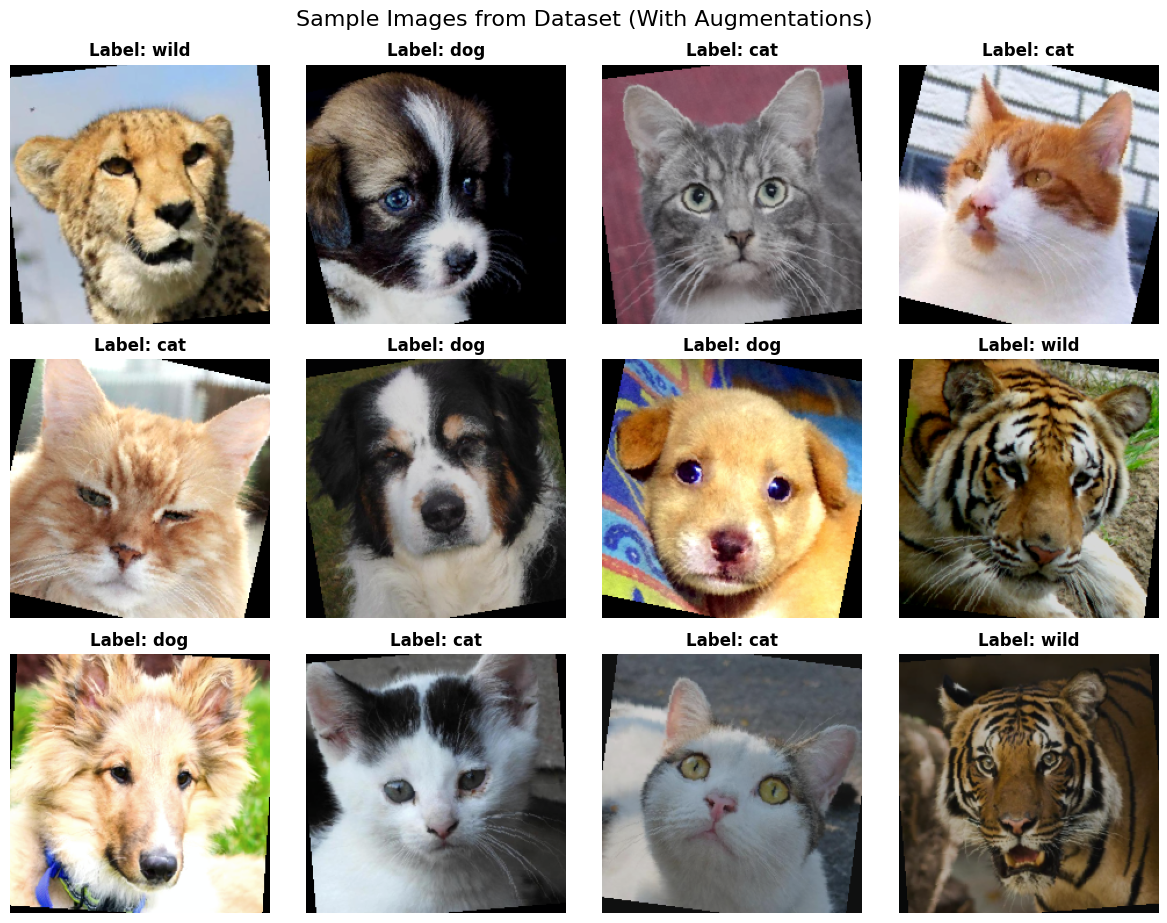

In [13]:
#visualizing the data
import matplotlib.pyplot as plt
import numpy as np

def visualize_data_grid(dataloader, num_images=12):
    """
    Displays a grid of images from the dataloader with their predicted labels.
    """
    # 1. Grab a single batch of data
    images, labels = next(iter(dataloader))

    # 2. Slice to the desired number of images
    images = images[:num_images]
    labels = labels[:num_images]

    # 3. Denormalize the images (reverse the transforms.Normalize step)
    # These are the standard ImageNet mean and std values you used in your dataset
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Convert tensor to numpy and change shape from (Batch, Channels, Height, Width)
    # to (Batch, Height, Width, Channels) for matplotlib
    images_np = images.numpy()
    images_np = np.transpose(images_np, (0, 2, 3, 1))

    # Apply denormalization and clip values to stay between 0 and 1
    images_np = std * images_np + mean
    images_np = np.clip(images_np, 0, 1)

    # 4. Setup the matplotlib grid
    cols = 4
    rows = (num_images + cols - 1) // cols  # Calculate required rows
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = axes.flatten() # Flatten to easily iterate

    # 5. Create a reverse mapping for labels (0 -> 'cat', 1 -> 'dog', etc.)
    idx_to_class = {v: k for k, v in dataloader.dataset.class_to_idx.items()}

    # 6. Plot each image
    for i, ax in enumerate(axes):
        if i < num_images:
            ax.imshow(images_np[i])
            class_name = idx_to_class[labels[i].item()]
            ax.set_title(f"Label: {class_name}", fontsize=12, fontweight='bold')
            ax.axis('off') # Hide axes ticks
        else:
            ax.axis('off') # Hide any extra empty subplots

    plt.tight_layout()
    plt.suptitle("Sample Images from Dataset (With Augmentations)", fontsize=16, y=1.02)
    plt.show()

# ==============================================================================
# RUN THE VISUALIZATION
# ==============================================================================
print("Generating image grid...")
visualize_data_grid(train_loader, num_images=12)

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AnimalConv2dScratch(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.linear = nn.Linear(self.in_channels * self.kernel_size * self.kernel_size, self.out_channels, bias=True)

    def forward(self, x):
        batch_size, channels, height, width = x.size()

        assert channels == self.in_channels, f"Input channels mismatch. Expected {self.in_channels}, got {channels}"

        # 1. Unfold the input into patches (Im2Col operation)
        # Shape: [batch_size, in_channels * kernel_size * kernel_size, num_patches]
        patches = F.unfold(
            x,
            kernel_size=self.kernel_size,
            stride=self.stride,
            padding=self.padding
        )

        # Store the number of kernel coefficients and patches
        _, num_kernel_coefficients, num_patches = patches.shape

        # 2. Transpose patches to shape [batch_size * num_patches, in_channels * kernel_size * kernel_size]
        patches = patches.transpose(1, 2).reshape(-1, num_kernel_coefficients)

        # 3. Apply the linear layer to perform convolution
        # Shape: [batch_size * num_patches, out_channels]
        conv_output = self.linear(patches)

        # 4. Reshape back to [batch_size, num_patches, out_channels]
        conv_output = conv_output.view(batch_size, -1, self.out_channels)

        # 5. Calculate explicit output dimensions
        output_height = (height + 2 * self.padding - self.kernel_size) // self.stride + 1
        output_width = (width + 2 * self.padding - self.kernel_size) // self.stride + 1

        # 6. Fold the patches back into image dimensions [batch_size, out_channels, height, width]
        output = conv_output.transpose(1, 2).view(batch_size, self.out_channels, output_height, output_width)

        return output

In [15]:
class AnimalClassificationNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.custom_conv1 = AnimalConv2dScratch(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.custom_conv2 = AnimalConv2dScratch(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.custom_conv3 = AnimalConv2dScratch(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.custom_conv1(x))))
        x = self.pool(F.relu(self.bn2(self.custom_conv2(x))))
        x = self.pool(F.relu(self.bn3(self.custom_conv3(x))))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

Training setup

In [ ]:
# ==============================================================================
# MODEL, LOSS, OPTIMIZER & QUEUES
# ==============================================================================
model = AnimalClassificationNet(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Queues for visualization
train_loss_queue = []
val_loss_queue = []
train_acc_queue = []
val_acc_queue = []

# ==============================================================================
# TRAINING LOOP
# ==============================================================================
EPOCHS = 10
PRINT_INTERVAL = 50

print("\n🚀 Starting Training Loop...\n")
for epoch in range(EPOCHS):
    start_time = time.time()

    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % PRINT_INTERVAL == 0:
            current_avg_loss = running_loss / total_train
            print(f"  ⏳ [Epoch {epoch+1}] Batch {batch_idx+1:3d}/{len(train_loader)} | Running Avg Loss: {current_avg_loss:.4f}")

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = (correct_train / total_train) * 100

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    elapsed_time = time.time() - start_time

    train_loss_queue.append(epoch_loss)
    val_loss_queue.append(epoch_val_loss)
    train_acc_queue.append(epoch_acc)
    val_acc_queue.append(epoch_val_acc)

    print(f"✅ Epoch [{epoch+1}/{EPOCHS}] ({elapsed_time:.1f}s) -> "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")
    print("-" * 60)

print("\n🎉 Training Complete!")


🚀 Starting Training Loop...

  ⏳ [Epoch 1] Batch  50/458 | Running Avg Loss: 4.0179
  ⏳ [Epoch 1] Batch 100/458 | Running Avg Loss: 2.4669


Plotting Function using the Queues

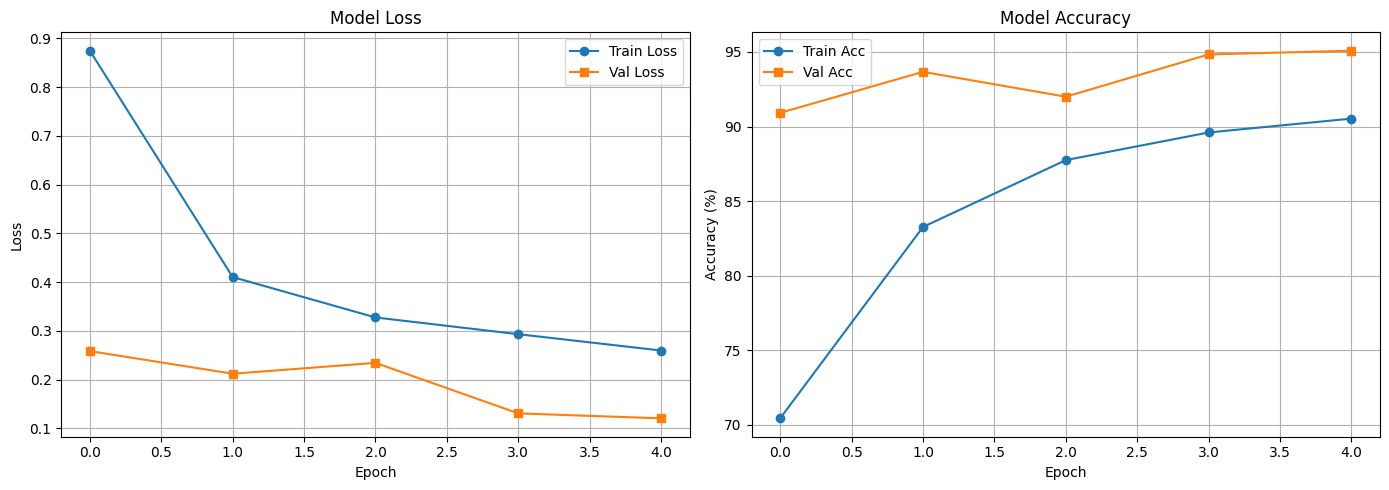

In [26]:
def plot_queues():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss (convert deque to list for matplotlib)
    ax1.plot(list(train_loss_queue), label='Train Loss', marker='o')
    ax1.plot(list(val_loss_queue), label='Val Loss', marker='s')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(list(train_acc_queue), label='Train Acc', marker='o')
    ax2.plot(list(val_acc_queue), label='Val Acc', marker='s')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Call the plot function after training
plot_queues()

In [27]:
# ==============================================================================
# 6. FINAL TESTING PHASE
# ==============================================================================
print("\n" + "="*60)
print("🧪 RUNNING FINAL EVALUATION ON TEST SET")
print("="*60)

try:
    model.load_state_dict(torch.load('best_animal_cnn.pth'))
    print("✅ Loaded best model weights from 'best_animal_cnn.pth'")
except FileNotFoundError:
    print("⚠️ Best model file not found. Using final epoch weights.")

model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()

final_test_loss = test_loss / len(test_dataset)
final_test_acc = (correct_test / total_test) * 100

print(f"🏆 FINAL TEST RESULTS:")
print(f"   Test Loss:     {final_test_loss:.4f}")
print(f"   Test Accuracy: {final_test_acc:.2f}%")
print("="*60)


🧪 RUNNING FINAL EVALUATION ON TEST SET
⚠️ Best model file not found. Using final epoch weights.
🏆 FINAL TEST RESULTS:
   Test Loss:     0.1433
   Test Accuracy: 95.90%


In [ ]:
torch.save(model.state_dict(), "animal_faces_model.pth")

In [ ]:
!pip install gradio --quiet

In [ ]:
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# CLASS LABELS
# =========================================================
class_names = ["cat", "dog", "wild"]

# =========================================================
# CUSTOM CONV (same as training)
# =========================================================
class AnimalConv2dScratch(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.linear = nn.Linear(
            in_channels * kernel_size * kernel_size,
            out_channels
        )

    def forward(self, x):
        batch_size, channels, height, width = x.size()

        patches = F.unfold(
            x,
            kernel_size=self.kernel_size,
            stride=self.stride,
            padding=self.padding
        )

        patches = patches.transpose(1, 2).reshape(-1, patches.size(1))

        out = self.linear(patches)

        output_h = (height + 2*self.padding - self.kernel_size)//self.stride + 1
        output_w = (width + 2*self.padding - self.kernel_size)//self.stride + 1

        out = out.view(batch_size, output_h * output_w, self.out_channels)
        out = out.transpose(1, 2).view(batch_size, self.out_channels, output_h, output_w)

        return out

# =========================================================
# MODEL ARCHITECTURE (must match training exactly)
# =========================================================
class AnimalClassificationNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.custom_conv1 = AnimalConv2dScratch(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.custom_conv2 = AnimalConv2dScratch(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.custom_conv3 = AnimalConv2dScratch(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.custom_conv1(x))))
        x = self.pool(F.relu(self.bn2(self.custom_conv2(x))))
        x = self.pool(F.relu(self.bn3(self.custom_conv3(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        return self.fc2(x)

# =========================================================
# LOAD MODEL
# =========================================================
model = AnimalClassificationNet(num_classes=3).to(device)
model.load_state_dict(torch.load("animal_faces_model.pth", map_location=device))
model.eval()

# =========================================================
# TRANSFORM
# =========================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================================================
# PREDICTION FUNCTION
# =========================================================
def predict(image):
    image = image.convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)[0]

    return {
        class_names[i]: float(probs[i])
        for i in range(len(class_names))
    }

# =========================================================
# GRADIO UI
# =========================================================
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="🐶 Animal Faces Classifier",
    description="Upload an image of a cat, dog, or wild animal and the model will classify it."
)

demo.launch()